<a href="https://colab.research.google.com/github/nashlypilar-collab/Intro_ciencia_tarea_grupo/blob/main/Fraudes_Feature_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.datasets import make_classification
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    classification_report,
    RocCurveDisplay
)

pd.set_option('display.max_columns', None)
rng = np.random.default_rng(42)

df = pd.read_csv("/content/fraudes.csv")

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  object 
 3   card_type                     20000 non-null  object 
 4   auth_method                   20000 non-null  object 
 5   channel                       20000 non-null  object 
 6   device_type                   20000 non-null  object 
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  a

**CASTEO VARIABLES**

In [32]:
df['is_fraud'] = df['is_fraud'].astype(bool)

In [33]:
# Convertir variables a category

nominales = ["transaction_id", "merchant_category", "card_type", "auth_method", "channel", "device_type"]
df[nominales] = df[nominales].astype("category")

In [34]:
# Convertir numéricas en categoricas ordinales
df["cvv_retry_count"] = pd.Categorical(
    df["cvv_retry_count"],
    categories=[0, 1, 2, 3],
    ordered=True
)

In [35]:
df["day_of_week"] = pd.Categorical(
    df["day_of_week"],
    categories=[0, 1, 2, 3, 4, 5, 6],
    ordered=True
)

In [36]:
df["prior_disputes"] = pd.Categorical(
    df["prior_disputes"],
    categories=[0, 1, 2, 3, 4],
    ordered=True
)

In [37]:
# Booleandas a enteras
columnas_bool = [
    "is_foreign_transaction",
    "is_new_merchant",
    "used_vpn",
    "ip_country_mismatch",
    "billing_shipping_mismatch",
    "is_ai_generated_scam_attempt",
    "is_fraud"
]

df[columnas_bool] = df[columnas_bool].astype(int)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   transaction_id                20000 non-null  category
 1   amount_usd                    20000 non-null  float64 
 2   merchant_category             20000 non-null  category
 3   card_type                     20000 non-null  category
 4   auth_method                   20000 non-null  category
 5   channel                       20000 non-null  category
 6   device_type                   20000 non-null  category
 7   is_foreign_transaction        20000 non-null  int64   
 8   hours_since_last_txn          20000 non-null  float64 
 9   txn_count_last_24h            20000 non-null  int64   
 10  distance_from_home_km         20000 non-null  float64 
 11  card_age_months               20000 non-null  int64   
 12  customer_age                  20000 non-null  

In [39]:
df.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,is_new_merchant,used_vpn,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud,montos_fraude,rango_horas,dia,card_age_quartile,device_group,market_group,grupo_mercado,balance_quartile
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,0,13.54,2,22.35,39,25,1080.71,0,0,0,0,0,0.1,18,3,0,42.3,0,0,Medio,Q4,Jueves,Q1 - Menor antigüedad,Android Phone,Restaurants,Consumo cotidiano,Q2 - Saldo bajo-medio
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,0,0.71,2,35.28,47,33,4463.72,1,0,0,0,0,25.8,12,4,0,28.3,0,0,Bajo,Q1,Viernes,Q2 - Antigüedad baja-media,Android Phone,Online Retail,Comercio digital,Q4 - Saldo alto
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,0,0.35,5,9.82,51,59,366.25,0,1,0,1,0,42.3,5,0,0,24.7,1,0,Alto,Q1,Lunes,Q3 - Antigüedad media-alta,Otros,Groceries,Consumo cotidiano,Q1 - Saldo bajo
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,0,3.42,6,19.72,48,28,1345.29,1,0,0,0,0,28.9,22,6,0,56.2,1,0,Bajo,Q2,Domingo,Q3 - Antigüedad media-alta,Android Phone,Otros,Entretenimiento digital,Q2 - Saldo bajo-medio
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,0,2.43,2,17.68,43,36,4192.59,0,0,0,0,0,3.9,2,4,0,32.7,0,0,Muy Alto,Q1,Viernes,Q2 - Antigüedad baja-media,iPhone,Otros,Servicios especializados,Q4 - Saldo alto


**TRAIN TEST SPLIT**

In [40]:
X = df.drop(columns='is_fraud')
y = df['is_fraud']

continuous1_cols = ['amount_usd','hours_since_last_txn','txn_count_last_24h','distance_from_home_km','customer_age','account_balance_usd']
continuous2_cols = ['card_age_months']
binary_cols = ['is_foreign_transaction','is_new_merchant','used_vpn','ip_country_mismatch','billing_shipping_mismatch']
cat_cols = ['transaction_id', 'merchant_category', 'card_type','auth_method', 'channel', 'device_type']
ord_cols = ['cvv_retry_count', 'day_of_week', 'prior_disputes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_train.shape, X_test.shape

((14000, 33), (6000, 33))

**Distribución de las variables**

array([[<Axes: title={'center': 'amount_usd'}>,
        <Axes: title={'center': 'hours_since_last_txn'}>],
       [<Axes: title={'center': 'txn_count_last_24h'}>,
        <Axes: title={'center': 'distance_from_home_km'}>],
       [<Axes: title={'center': 'customer_age'}>,
        <Axes: title={'center': 'account_balance_usd'}>]], dtype=object)

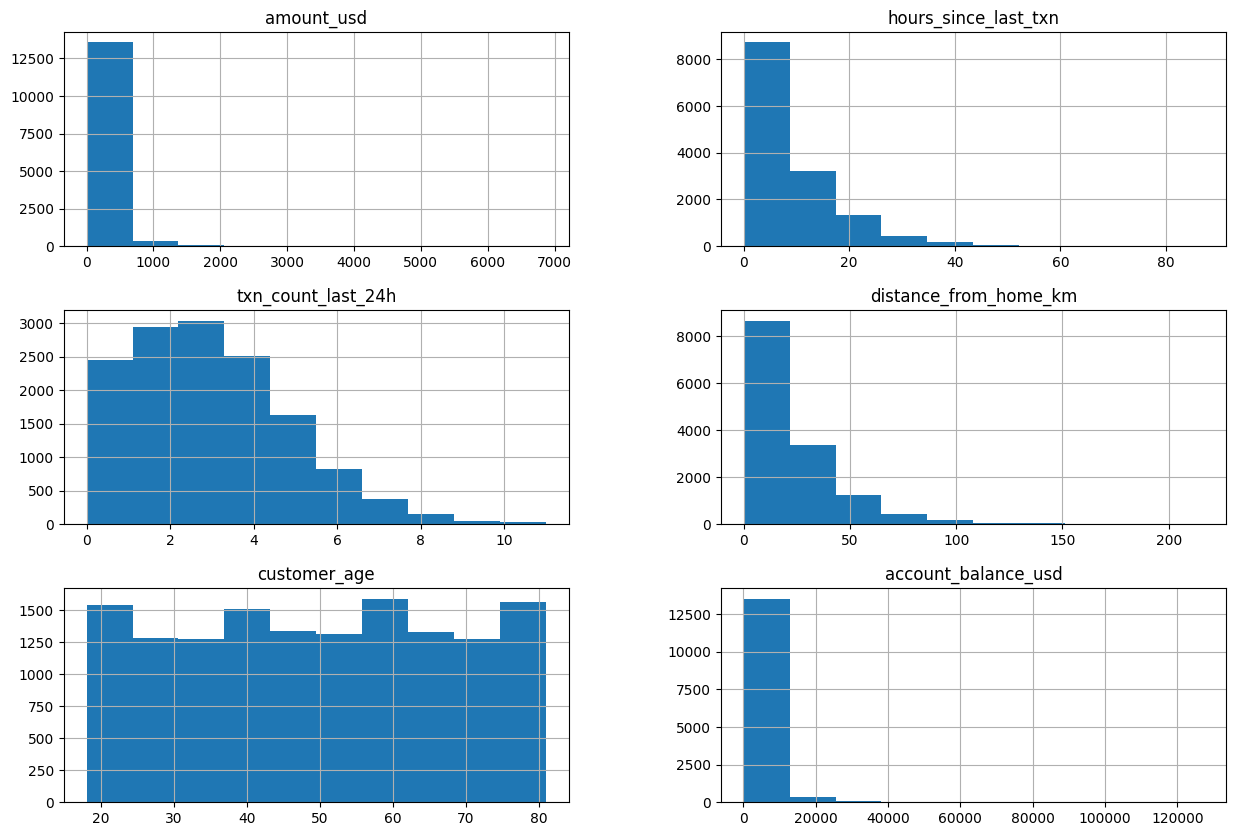

In [41]:
X_train[continuous1_cols].hist(figsize=(15, 10))

In [42]:
X_train.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,is_new_merchant,used_vpn,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,montos_fraude,rango_horas,dia,card_age_quartile,device_group,market_group,grupo_mercado,balance_quartile
5440,5441,104.86,Restaurants,Amex,No Authentication,Online,POS Terminal,0,10.67,1,26.79,45,27,884.29,1,0,0,0,0,8.7,11,1,0,20.2,0,Alto,Q3,Martes,Q2 - Antigüedad baja-media,POS Terminal,Restaurants,Consumo cotidiano,Q1 - Saldo bajo
10570,10571,64.35,Restaurants,Mastercard,OTP,In-App,Android Phone,0,1.84,6,27.67,55,35,2640.11,0,0,0,0,0,33.5,22,3,0,32.1,1,Alto,Q1,Jueves,Q4 - Mayor antigüedad,Android Phone,Restaurants,Consumo cotidiano,Q3 - Saldo medio-alto
7784,7785,191.73,Online Retail,Visa,PIN,POS,Mac,0,9.56,2,11.29,47,20,5455.10,0,0,0,0,0,22.5,7,4,0,49.8,1,Muy Alto,Q3,Viernes,Q2 - Antigüedad baja-media,Otros,Online Retail,Comercio digital,Q4 - Saldo alto
11121,11122,28.29,Online Retail,Visa,3D Secure,Contactless,Android Phone,0,21.65,4,6.50,51,57,1023.18,0,0,0,0,0,15.8,1,3,0,42.9,0,Medio,Q4,Jueves,Q3 - Antigüedad media-alta,Android Phone,Online Retail,Comercio digital,Q2 - Saldo bajo-medio
2104,2105,194.99,Groceries,Visa,PIN,In-App,Tablet,0,2.57,4,7.33,39,81,5544.18,0,0,0,0,0,16.4,5,6,0,28.3,0,Muy Alto,Q1,Domingo,Q1 - Menor antigüedad,Otros,Groceries,Consumo cotidiano,Q4 - Saldo alto


PIPELINE CATEGORICAS Y NUMÉRICAS

In [43]:
# Excluir el identificador y la variable objetivo de las características
X = df.drop(columns=["is_fraud", "transaction_id"])
y = df["is_fraud"]

# Quitar transaction_id de la lista de variables categóricas
cat_cols = [
    columna for columna in cat_cols
    if columna != "transaction_id"
]

# Vuelve a ejecutar desde aquí las celdas de división,
# creación del preprocesador y entrenamiento del modelo.

In [44]:
numeric_robust = Pipeline(steps=[
    ('scaler', RobustScaler())
])

numeric_standard = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_simple = Pipeline(steps=[
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

categorical_ordinal = Pipeline(steps=[
    ('ord', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

preprocessor = ColumnTransformer([
    ('continuous_robust', numeric_robust, continuous1_cols),
    ('continuous_standard', numeric_standard, continuous2_cols),
    ('binary', 'passthrough', binary_cols),
    ('nom', categorical_simple, cat_cols),
    ('ord', categorical_ordinal, ord_cols)
])

model_simple = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

model_simple.fit(X_train, y_train)

pred_proba_simple = model_simple.predict_proba(X_test)[:, 1]

print(
    'AUC RobustScaler:',
    round(roc_auc_score(y_test, pred_proba_simple), 4)
)

AUC RobustScaler: 0.888


En el pipeline se tomaron diferentes formas de escalar, ya que el DF cuenta con variables de diferentes distribuciones.
Se utilizó RobustScaler con variables con muchos outliers y el StandardScaler con variables que tendían a tener una distribución mas normal o variables binarias.

## **Entrenar un modelo base**

In [45]:
y_pred = model_simple.predict(X_test)
y_pred_proba = model_simple.predict_proba(X_test)[:, 1]

pd.DataFrame({
    'real': y_test.head(10).values,
    'pred': y_pred[:10],
    'proba_clase_1': y_pred_proba[:10]
})

,real,pred,proba_clase_1
0,0,0,0.150360
1,0,0,0.084645
2,0,0,0.124018
3,0,0,0.087565
4,0,0,0.035829
5,0,0,0.124452
6,0,0,0.007437
7,0,0,0.055883
8,0,0,0.036429
9,0,0,0.082397


## **Matriz de confusión**

In [46]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[5034,  864],
       [  27,   75]])

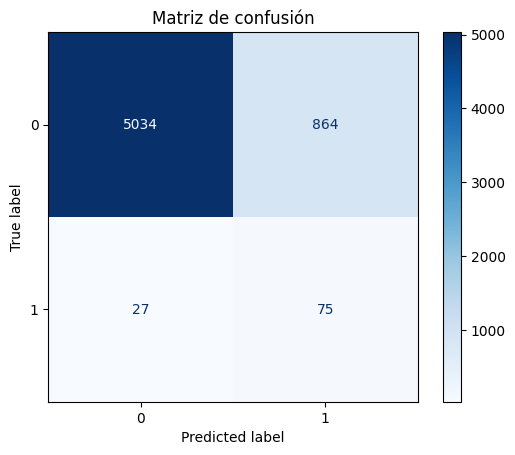

In [47]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title('Matriz de confusión')
plt.show()

In [48]:
tn, fp, fn, tp = cm.ravel()

pd.DataFrame({
    'valor': [tn, fp, fn, tp]
}, index=['TN', 'FP', 'FN', 'TP'])

,valor
TN,5034
FP,864
FN,27
TP,75


## **Probando diferentes Threshold**

In [49]:
thresholds = [1.00, 0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60, 0.55,
              0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10, 0.05, 0.00]

resultados = []

for threshold in thresholds:

    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    resultados.append([
        threshold,
        tp,
        tn,
        fp,
        fn,
        accuracy,
        precision,
        recall,
        specificity,
        f1
    ])

tabla_thresholds = pd.DataFrame(
    resultados,
    columns=[
        'Threshold',
        'TP',
        'TN',
        'FP',
        'FN',
        'Accuracy',
        'Precision',
        'Recall',
        'Specificity',
        'F1'
    ]
)

tabla_thresholds.round(3)

,Threshold,TP,TN,FP,FN,Accuracy,Precision,Recall,Specificity,F1
0,1.00,0,5898,0,102,0.983,0.000,0.000,1.000,0.000
1,0.95,25,5845,53,77,0.978,0.321,0.245,0.991,0.278
2,0.90,35,5781,117,67,0.969,0.230,0.343,0.980,0.276
3,0.85,45,5707,191,57,0.959,0.191,0.441,0.968,0.266
4,0.80,49,5627,271,53,0.946,0.153,0.480,0.954,0.232
5,0.75,55,5537,361,47,0.932,0.132,0.539,0.939,0.212
6,0.70,60,5444,454,42,0.917,0.117,0.588,0.923,0.195
7,0.65,64,5340,558,38,0.901,0.103,0.627,0.905,0.177
8,0.60,67,5256,642,35,0.887,0.094,0.657,0.891,0.165
9,0.55,70,5140,758,32,0.868,0.085,0.686,0.871,0.151


Umbral: 0.15 | Recall: 0.951 | Precision: 0.0381 | TP: 97 | FP: 2448 | FN: 5


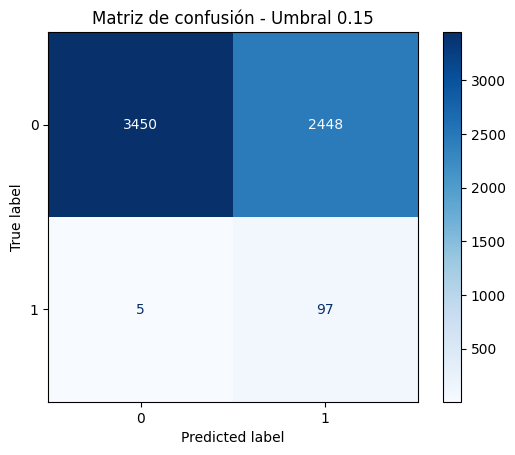

Umbral: 0.05 | Recall: 1.0 | Precision: 0.0251 | TP: 102 | FP: 3956 | FN: 0


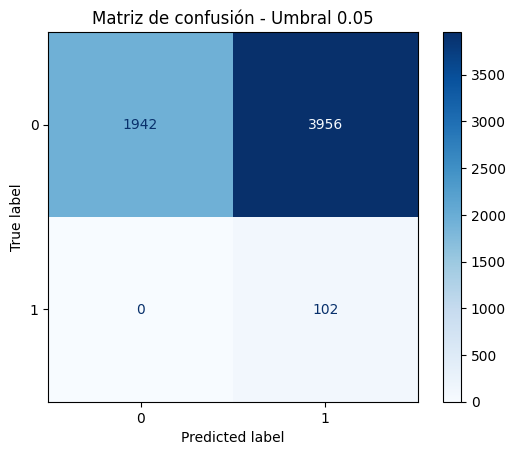

In [50]:
y_pred_proba = model_simple.predict_proba(X_test)[:, 1]

for threshold in [0.15, 0.05]:

    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    recall = tp / (tp + fn)
    precision = tp / (tp + fp)

    print(
        'Umbral:', threshold,
        '| Recall:', round(recall, 4),
        '| Precision:', round(precision, 4),
        '| TP:', tp,
        '| FP:', fp,
        '| FN:', fn
    )

    cm = confusion_matrix(y_test, y_pred_threshold)

    ConfusionMatrixDisplay(
        confusion_matrix=cm
    ).plot(cmap='Blues')

    plt.title(f'Matriz de confusión - Umbral {threshold}')
    plt.show()


Al ver que el modelo con el porcentaje que arroja el primer pipeline no tiene un nivel de sensibilidad adecuado al fraude, obtamos por elegir un umbral entre 0,05 y 0,15 debido a nos acercan al objetivo de predecir la mayor cantidad de fraudes posibles.

Al reducir el umbral a 0.05, el modelo detectó 91 de los 102 fraudes reales, alcanzando un recall del 89.2 %. Aunque aumentaron los falsos positivos, consideramos que es preferible generar más alertas que dejar pasar una mayor cantidad de fraudes.

Por otra parte, el umbral de 0,15 nos permite tener un modelo un poco mas equilibrado sin aumentar el número de falsos positivos.


## **Métricas del Modelo**

Nos quedamos con el Threshold = 0.05

In [51]:
y_pred_proba = model_simple.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.05).astype(int)

Accuracy: 0.3407
Precision: 0.0251
Recall: 1.0
F1: 0.049
AUC: 0.888


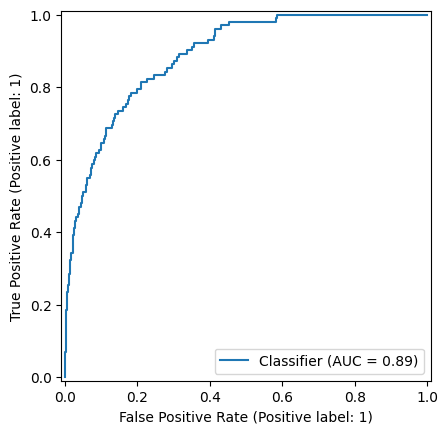

In [52]:
#Calcular las diferentes métricas

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print('Accuracy:', round(acc, 4))
print('Precision:', round(prec, 4))
print('Recall:', round(rec, 4))
print('F1:', round(f1, 4))
print('AUC:', round(auc, 4))

RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.show()

El modelo con umbral de 0.05 prioriza la detección de fraudes, alcanzando un Recall de 89.22 %. Esto significa que detecta 91 de los 102 fraudes reales. Sin embargo, esta mayor detección genera muchas falsas alarmas, por lo que la Precision disminuye a 4.78 %. El AUC de 89.91 % muestra que el modelo mantiene una buena capacidad para diferenciar entre fraude y no fraude.

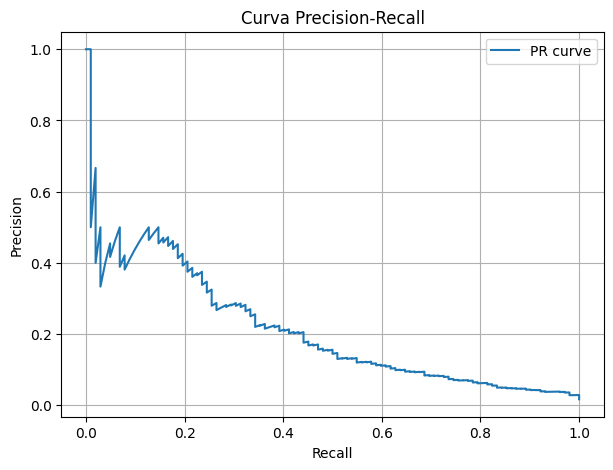

Average Precision: 0.2135


In [53]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_pred_proba)

ap = average_precision_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend(['PR curve'])
plt.grid()
plt.show()

print('Average Precision:', round(ap, 4))

La curva Precision-Recall muestra que existe un intercambio entre la detección de fraudes y las falsas alarmas. Al aumentar el Recall, la Precision disminuye. Esto significa que, para detectar una mayor cantidad de fraudes, debemos aceptar un mayor número de falsas alarmas. El Average Precision obtenido fue de 21.87 %, lo que resume este comportamiento de la curva.

## **Feature Importance**

In [54]:
feature_names = model_simple.named_steps['prep'].get_feature_names_out()
coefficients = model_simple.named_steps['clf'].coef_[0]

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

feature_importance.head(20)

,feature,coefficient,abs_coefficient
10,binary__ip_country_mismatch,2.513867,2.513867
11,binary__billing_shipping_mismatch,2.298311,2.298311
47,ord__cvv_retry_count,1.866564,1.866564
7,binary__is_foreign_transaction,1.448108,1.448108
16,nom__merchant_category_Gift Cards,1.443493,1.443493
9,binary__used_vpn,1.417826,1.417826
31,nom__auth_method_No Authentication,1.398586,1.398586
8,binary__is_new_merchant,1.341907,1.341907
30,nom__auth_method_Biometric,-1.200453,1.200453
22,nom__merchant_category_Travel,-1.129764,1.129764
